Script based on https://bookdown.org/amesoudi/ABMtutorial_bookdown/model15.html

With added comments and some modifications by AB

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

np.random.seed(42)

## A. Simple mixed population

### A1. Population setup

We start with a simple transmission model. The population has $n$ individuals, each expressing one of $b$ possible behaviours (e.g., greeting with a handshake vs. elbow bump). The entire population is represented as a vector `behaviours`.

In [2]:
n = 100   # population size
b = 2     # number of possible behaviours

behaviours = np.random.choice(np.arange(1, b + 1), size=n, replace=True)
behaviours

array([1, 2, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 1, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1])

### A2. Unbiased copying

Each time step, a random individual copies the behaviour of another randomly selected individual (**unbiased copying**).

We simulate `r_max` copying events and record the frequency of each behaviour at every step.

In [3]:
r_max = 1000
rec_behav = pd.DataFrame({"time": np.arange(1, r_max + 1),
                           "b1": np.zeros(r_max),
                           "b2": np.zeros(r_max)})

for round_ in range(r_max):
    # Unbiased copying: a random individual adopts a randomly sampled behaviour
    observer = np.random.randint(n)
    behaviours[observer] = behaviours[np.random.randint(n)]
    rec_behav.loc[round_, "b1"] = np.sum(behaviours == 1)
    rec_behav.loc[round_, "b2"] = np.sum(behaviours == 2)

rec_behav

,time,b1,b2
0,1,43.0,57.0
1,2,43.0,57.0
2,3,43.0,57.0
3,4,43.0,57.0
4,5,42.0,58.0
...,...,...,...
995,996,21.0,79.0
996,997,21.0,79.0
997,998,21.0,79.0
998,999,21.0,79.0


### A3. Tidying the data & plotting

To plot the data properly, we need to change the data to a *tidy* format.

**Reminder:** a table is considered *tidy* when each variable is a column and each observation is a row.

Here, we need to merge `b1` and `b2` into a single column that we will name `behaviour`, and to transfer their values in another column, `freq`. We can do that with the `melt` function from pandas.

In [4]:
# Convert to long format (i.e., tidy) for plotting
tidy_rec_behav = rec_behav.melt(id_vars="time", var_name="behaviour", value_name="freq")
tidy_rec_behav

,time,behaviour,freq
0,1,b1,43.0
1,2,b1,43.0
2,3,b1,43.0
3,4,b1,43.0
4,5,b1,42.0
...,...,...,...
1995,996,b2,79.0
1996,997,b2,79.0
1997,998,b2,79.0
1998,999,b2,79.0


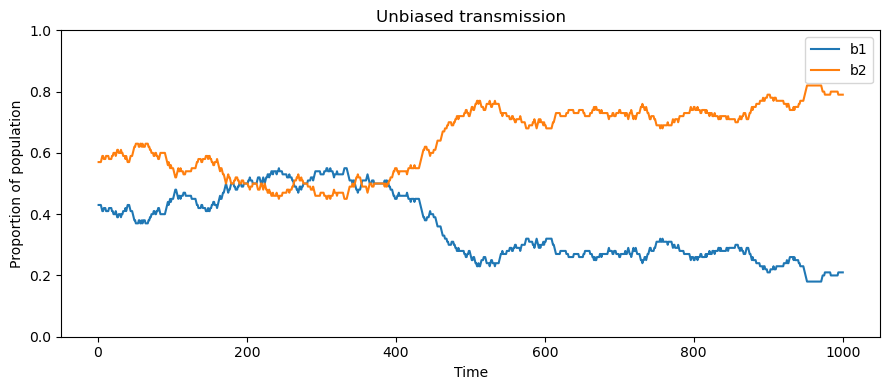

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
for beh, grp in tidy_rec_behav.groupby("behaviour"):
    ax.plot(grp["time"], grp["freq"] / n, label=beh)
ax.set_ylim(0, 1)
ax.set_title("Unbiased transmission")
ax.set_xlabel("Time")
ax.set_ylabel("Proportion of population")
ax.legend()
plt.tight_layout()
plt.show()

### A4. Function wrapping

As expected from unbiased transmission, the frequency of the two behaviours fluctuates around $0.5$. We wrap this into a reusable function:

In [6]:
def mixed_population(n, b, r_max):
    """Simple mixed unbiased transmission.

    Parameters
    ----------
    n     (int): population size
    b     (int): number of behaviours
    r_max (int): number of time steps

    Returns
    -------
    pd.DataFrame (long format): columns time, behaviour, freq
    """
    behaviours = np.random.choice(np.arange(1, b + 1), size=n, replace=True)
    rows = []

    for round_ in range(r_max):
        observer = np.random.randint(n)
        behaviours[observer] = behaviours[np.random.randint(n)]
        for bi in range(b):
            rows.append({
                "time":      round_,
                "behaviour": f"b{bi + 1}",
                "freq":      np.sum(behaviours == bi + 1) / n
            })

    return pd.DataFrame(rows)

### A5. Small population test

With a very small population ($n=20$), drift will eventually fix one behaviour:

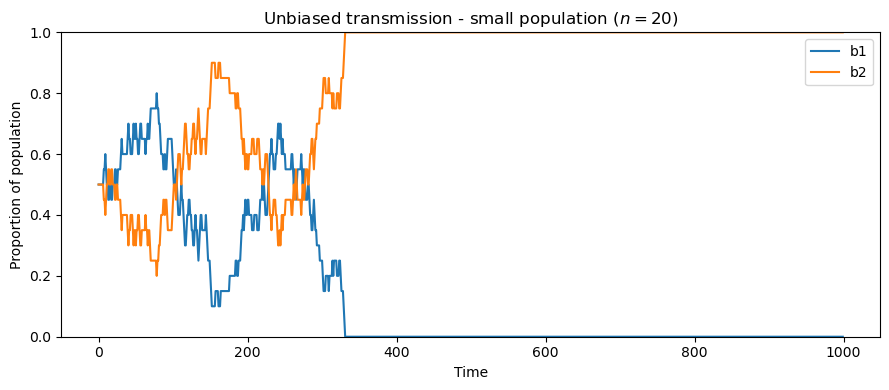

In [7]:
n = 20

res = mixed_population(n, b=2, r_max=1000)

fig, ax = plt.subplots(figsize=(9, 4))
for beh, grp in res.groupby("behaviour"):
    ax.plot(grp["time"], grp["freq"], label=beh)
ax.set_ylim(0, 1)
ax.set_xlabel("Time")
ax.set_ylabel("Proportion of population")
ax.set_title("Unbiased transmission - small population ($n=20$)")
ax.legend()
plt.tight_layout()
plt.show()

### A6. Exercise

We want to investigate the impact of population size on population wide convergence.

Set code to investigate the effect of varying *n* on the number of population that converge (i.e., with one of two behaviours going to 100% frequency).

Run multiple simulation to minimize the effect of random.

In this exercice, I want you to:
- Think of good values for *n* to test
- Think of the number of simulation that you think are enough for neat results
- Implement a multi-simulation run of the model & store the data
- Think of a metric to show the rate of convergence for each size *n* of the population
- Plot your results

## B. Subdivided population with limited contact

#### B1. Subdivded population model with uniform copying

We now divide the population into $c$ clusters, each of size $n$. Individuals still copy uniformly across the *whole* population, so the clusters are statistically independent subsets.

We track $p$, the proportion of behaviour 1, in each cluster over time.
We assume that there are the same number, $n$, of individuals in each cluster, $c$.

In [12]:
def subdivided_population_uniform(n, c, r_max):
    """Subdivided population with copying still uniform across the whole population.

    Parameters
    ----------
    n     (int): agents per cluster
    c     (int): number of clusters
    r_max (int): number of time steps

    Returns
    -------
    pd.DataFrame: columns time, cluster, p
    """
    total_pop  = c * n
    cluster    = np.repeat(np.arange(c), n)
    behaviours = np.random.choice([1, 2], size=total_pop, replace=True)
    rows = []

    for round_ in range(r_max):
        observer = np.random.randint(total_pop)
        behaviours[observer] = behaviours[np.random.randint(total_pop)]
        for clu in range(c):
            mask = cluster == clu
            rows.append({
                "time":    round_,
                "cluster": clu,
                "p":       np.sum(behaviours[mask] == 1) / n
            })

    return pd.DataFrame(rows)

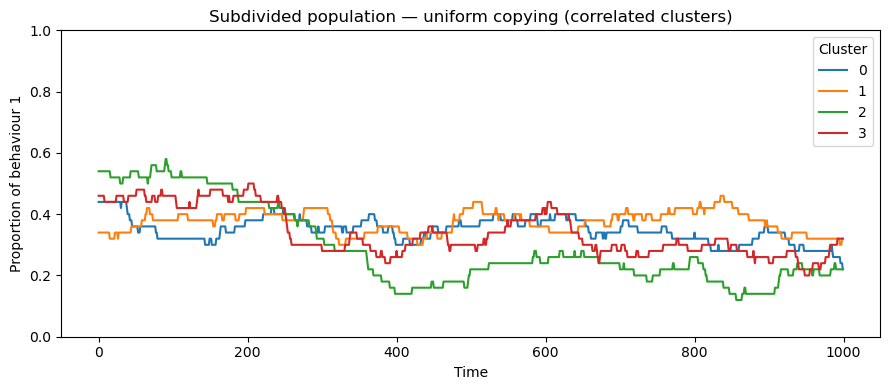

In [13]:
res = subdivided_population_uniform(n=50, c=4, r_max=1000)

fig, ax = plt.subplots(figsize=(9, 4))
for clu, grp in res.groupby("cluster"):
    ax.plot(grp["time"], grp["p"], label=clu)
ax.set_ylim(0, 1)
ax.set_xlabel("Time")
ax.set_ylabel("Proportion of behaviour 1")
ax.set_title("Subdivided population — uniform copying (correlated clusters)")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

The frequency in all clusters is correlated because copying is still uniform across the whole population. Fluctuations are purely stochastic.

#### B2. Subdivided population with ingroup preference

Now we modify the model so that individuals **preferentially** learn from members of their own cluster. We achieve this using a probability weight vector: agents in the same cluster have weight 1, others have weight 0.

In [14]:
def structured_population_ingroup_preference(n, c, r_max):
    """Within-cluster copying only.

    An observer copies exclusively from individuals in the same cluster.

    Parameters
    ----------
    n     (int): agents per cluster
    c     (int): number of clusters
    r_max (int): number of time steps

    Returns
    -------
    pd.DataFrame: columns time, cluster, p
    """
    total_pop  = c * n
    cluster    = np.repeat(np.arange(c), n)
    behaviours = np.random.choice([1, 2], size=total_pop, replace=True)
    rows = []

    for round_ in range(r_max):
        cluster_id   = np.random.randint(c)
        same_cluster = np.where(cluster == cluster_id)[0]

        if len(same_cluster) > 1:
            obs, dem = np.random.choice(same_cluster, size=2, replace=False)
            behaviours[obs] = behaviours[dem]

        for clu in range(c):
            mask = cluster == clu
            rows.append({
                "time":    round_,
                "cluster": clu,
                "p":       np.sum(behaviours[mask] == 1) / n
            })

    return pd.DataFrame(rows)

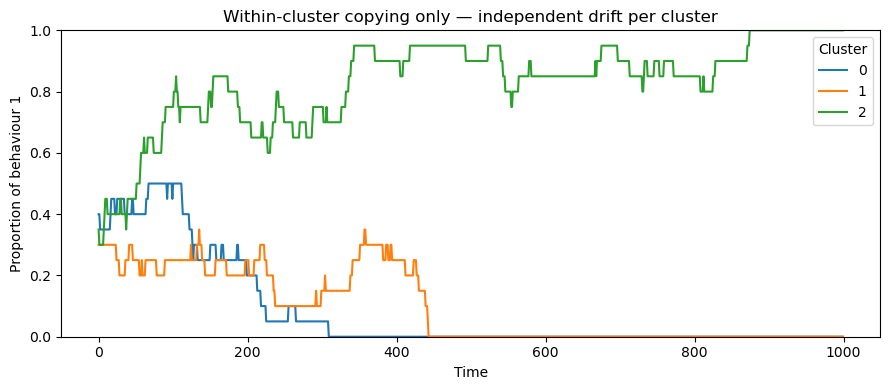

In [15]:
res = structured_population_ingroup_preference(n=20, c=3, r_max=1000)

fig, ax = plt.subplots(figsize=(9, 4))
for clu, grp in res.groupby("cluster"):
    ax.plot(grp["time"], grp["p"], label=clu)
ax.set_ylim(0, 1)
ax.set_xlabel("Time")
ax.set_ylabel("Proportion of behaviour 1")
ax.set_title("Within-cluster copying only — independent drift per cluster")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

Each cluster now drifts independently. We are essentially simulating $c$ small, isolated populations.

#### B3. Adding a contact probability $p_c$

Let $s=1$ if the demonstrator is in the same cluster as the observer, and $s=0$ otherwise. The sampling weight is:

$$\omega = \frac{s + p_c}{1 + p_c}$$

With $p_c = 0$ we recover strict within-cluster copying; with $p_c = 1$ we recover uniform copying across the whole population.

In [16]:
def structured_population_contact(n, c, p_c, r_max):
    """Within-cluster copying with contact probability p_c.

    Parameters
    ----------
    n     (int)  : agents per cluster
    c     (int)  : number of clusters
    p_c   (float): contact probability (0 = no inter-cluster contact)
    r_max (int)  : number of time steps

    Returns
    -------
    pd.DataFrame: columns time, cluster, p
    """
    total_pop  = c * n
    cluster    = np.repeat(np.arange(c), n)
    behaviours = np.random.choice([1, 2], size=total_pop, replace=True)
    rows = []

    for round_ in range(r_max):
        cluster_id = np.random.randint(c)
        s          = (cluster == cluster_id).astype(float)
        weights    = (s + p_c) / (1 + p_c)

        if np.sum(cluster == cluster_id) > 1:
            chosen = np.random.choice(total_pop, size=2, replace=False, p=weights / weights.sum())
            behaviours[chosen[0]] = behaviours[chosen[1]]

        for clu in range(c):
            mask = cluster == clu
            rows.append({
                "time":    round_,
                "cluster": clu,
                "p":       np.sum(behaviours[mask] == 1) / n
            })

    return pd.DataFrame(rows)

Let us compare three contact probabilities: no contact, some contact, and full contact.

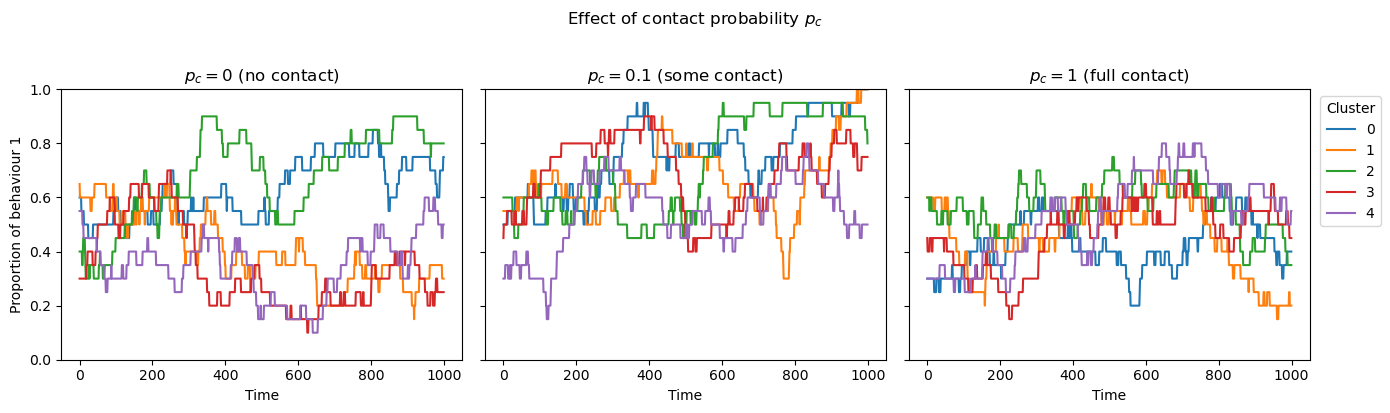

In [17]:
res_pc0  = structured_population_contact(n=20, c=5, p_c=0,   r_max=1000)
res_pc01 = structured_population_contact(n=20, c=5, p_c=0.1, r_max=1000)
res_pc1  = structured_population_contact(n=20, c=5, p_c=1,   r_max=1000)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, res, title in zip(axes,
                          [res_pc0, res_pc01, res_pc1],
                          ["$p_c = 0$ (no contact)",
                           "$p_c = 0.1$ (some contact)",
                           "$p_c = 1$ (full contact)"]):
    for clu, grp in res.groupby("cluster"):
        ax.plot(grp["time"], grp["p"], label=clu)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_title(title)

axes[0].set_ylabel("Proportion of behaviour 1")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("Effect of contact probability $p_c$", y=1.02)
plt.tight_layout()
plt.show()

- With $p_c = 0$ clusters evolve independently.
- As $p_c$ increases, cluster frequencies become correlated.
- At $p_c = 1$ the model is equivalent to a single well-mixed population.

## C. Subdivided populations with migration

### C1. Model

Instead of cultural traits moving between clusters (contact), individuals themselves can move, carrying their behaviour with them. We add a **migration probability** $p_m$: after a copying event, the observer moves to a randomly chosen different cluster with probability $p_m$.

In [18]:
def structured_population_migration(n, c, p_c, p_m, r_max):
    """Subdivided population with contact and migration.

    Parameters
    ----------
    n     (int)  : agents per cluster
    c     (int)  : number of clusters
    p_c   (float): contact probability
    p_m   (float): migration probability
    r_max (int)  : number of time steps

    Returns
    -------
    pd.DataFrame: columns time, cluster, p
    """
    total_pop  = c * n
    cluster    = np.repeat(np.arange(c), n).astype(int)
    behaviours = np.random.choice([1, 2], size=total_pop, replace=True)
    rows = []

    for round_ in range(r_max):
        cluster_id = np.random.randint(c)
        s          = (cluster == cluster_id).astype(float)
        weights    = (s + p_c) / (1 + p_c)

        observer = None
        if np.sum(cluster == cluster_id) > 1:
            chosen   = np.random.choice(total_pop, size=2, replace=False, p=weights / weights.sum())
            observer = chosen[0]
            behaviours[observer] = behaviours[chosen[1]]

        if observer is not None and (np.random.uniform() <= p_m) and c > 1:
            other_clusters   = [ci for ci in range(c) if ci != cluster_id]
            cluster[observer] = np.random.choice(other_clusters)

        for clu in range(c):
            mask  = cluster == clu
            n_clu = np.sum(mask)
            rows.append({
                "time":    round_,
                "cluster": clu,
                "p":       np.sum(behaviours[mask] == 1) / n_clu if n_clu > 0 else np.nan
            })

    return pd.DataFrame(rows)

We compare three migration rates. We run the simulation longer ($r_{max}=10{,}000$) to allow fixation to occur.

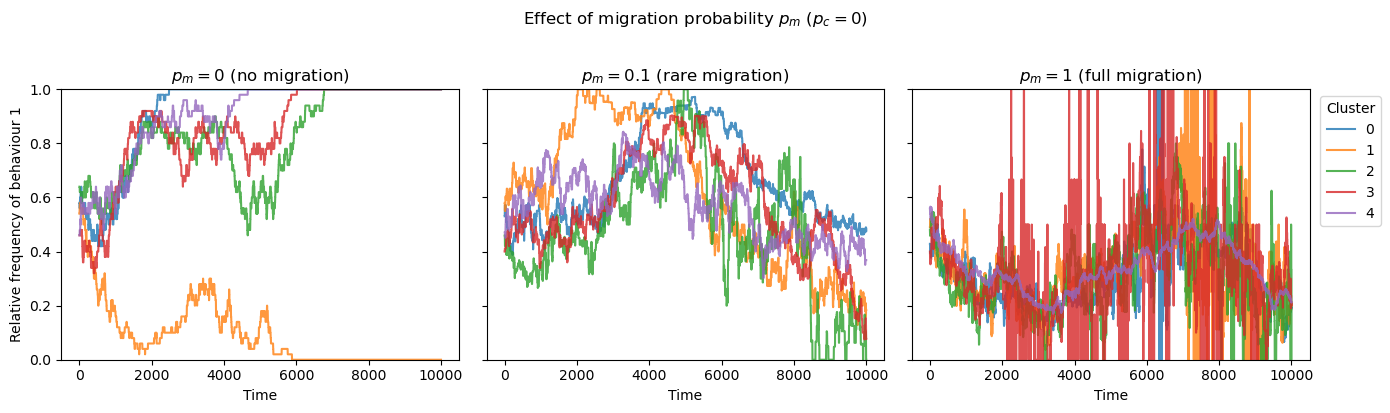

In [19]:
res_pm0  = structured_population_migration(c=5, n=50, r_max=10000, p_m=0,   p_c=0)
res_pm1  = structured_population_migration(c=5, n=50, r_max=10000, p_m=1,   p_c=0)
res_pm01 = structured_population_migration(c=5, n=50, r_max=10000, p_m=0.1, p_c=0)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, res, title in zip(axes,
                          [res_pm0, res_pm01, res_pm1],
                          ["$p_m = 0$ (no migration)",
                           "$p_m = 0.1$ (rare migration)",
                           "$p_m = 1$ (full migration)"]):
    for clu, grp in res.groupby("cluster"):
        ax.plot(grp["time"], grp["p"], label=clu, alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Time")
    ax.set_title(title)

axes[0].set_ylabel("Relative frequency of behaviour 1")
axes[2].legend(title="Cluster", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.suptitle("Effect of migration probability $p_m$ ($p_c = 0$)", y=1.02)
plt.tight_layout()
plt.show()

- $p_m = 0$: clusters act as independent populations and fix independently.
- $p_m = 1$: constant shuffling correlates all clusters; they fix together.
- $p_m = 0.1$: intermediate; occasional jumps between clusters but clusters can still diverge.

### C2. Exercise

You may have noticed that with a lot of migration, the curve for some clusters jumps between 0 and 1. This is the case when a cluster is almost empty, and the last individual migrates.

To investigate this phenomenom and get some insight, we want to plot for each time step the population of all clusters.

In this exercice, I want you to:
- Inspect the data you have when you run `structure_population_migration`
- If `n` is missing from the data, modify `structure_population_migration` to keep track of it
- Plot the results

## D. Parameter exploration

To systematically compare the effect of $p_c$ and $p_m$ we track the **variance** in the frequency of behaviour 1 *across clusters* at each time step. High variance means clusters are very different from one another; low variance means they behave like a single population.

### D1. Model for parameter exploration

In [24]:
def structured_population(n, c, p_c, p_m, r_max, sim=1):
    """Like structured_population_migration but returns variance between clusters over time.

    Parameters
    ----------
    n     (int)  : agents per cluster
    c     (int)  : number of clusters
    p_c   (float): contact probability
    p_m   (float): migration probability
    r_max (int)  : number of time steps
    sim   (int)  : simulation ID (for bookkeeping)

    Returns
    -------
    pd.DataFrame: columns time, var, sim, p_c, p_m
    """
    total_pop  = c * n
    cluster    = np.repeat(np.arange(c), n).astype(int)
    behaviours = np.random.choice([1, 2], size=total_pop, replace=True)
    rows = []

    for round_ in range(r_max):
        cluster_id = np.random.randint(c)
        s          = (cluster == cluster_id).astype(float)
        weights    = (s + p_c) / (1 + p_c)

        observer = None
        if np.sum(cluster == cluster_id) > 1:
            chosen   = np.random.choice(total_pop, size=2, replace=False, p=weights / weights.sum())
            observer = chosen[0]
            behaviours[observer] = behaviours[chosen[1]]

        if observer is not None and (np.random.uniform() <= p_m) and c > 1:
            other_clusters    = [ci for ci in range(c) if ci != cluster_id]
            cluster[observer] = np.random.choice(other_clusters)

        freq = np.array([
            np.sum(behaviours[cluster == clu] == 1) / np.sum(cluster == clu)
            if np.sum(cluster == clu) > 0 else np.nan
            for clu in range(c)
        ])

        rows.append({
            "time": round_,
            "var":  np.nanvar(freq),
            "sim":  sim,
            "p_c":  p_c,
            "p_m":  p_m
        })

    return pd.DataFrame(rows)

### D2. Run

We run 20 replicates for each combination of $p_m, p_c \in \{0, 0.01, 0.1, 1\}$ — $4 \times 4 \times 20 = 320$ simulations in total.

In [25]:
pm_values = [0, 0.01, 0.1, 1]
pc_values = [0, 0.01, 0.1, 1]
n_reps    = 20

grid = list(itertools.product(range(n_reps), pm_values, pc_values))

results = []
for sim_id, (rep, pm, pc) in enumerate(grid):
    results.append(
        structured_population(c=5, n=20, r_max=2000, p_m=pm, p_c=pc, sim=sim_id)
    )

res = pd.concat(results, ignore_index=True)
res.head()

,time,var,sim,p_c,p_m
0,0,0.0046,0,0.0,0.0
1,1,0.0046,0,0.0,0.0
2,2,0.0054,0,0.0,0.0
3,3,0.0070,0,0.0,0.0
4,4,0.0074,0,0.0,0.0


### D3. Plotting

Now we plot the variance over time, faceted by $p_m$ (rows) and $p_c$ (columns):

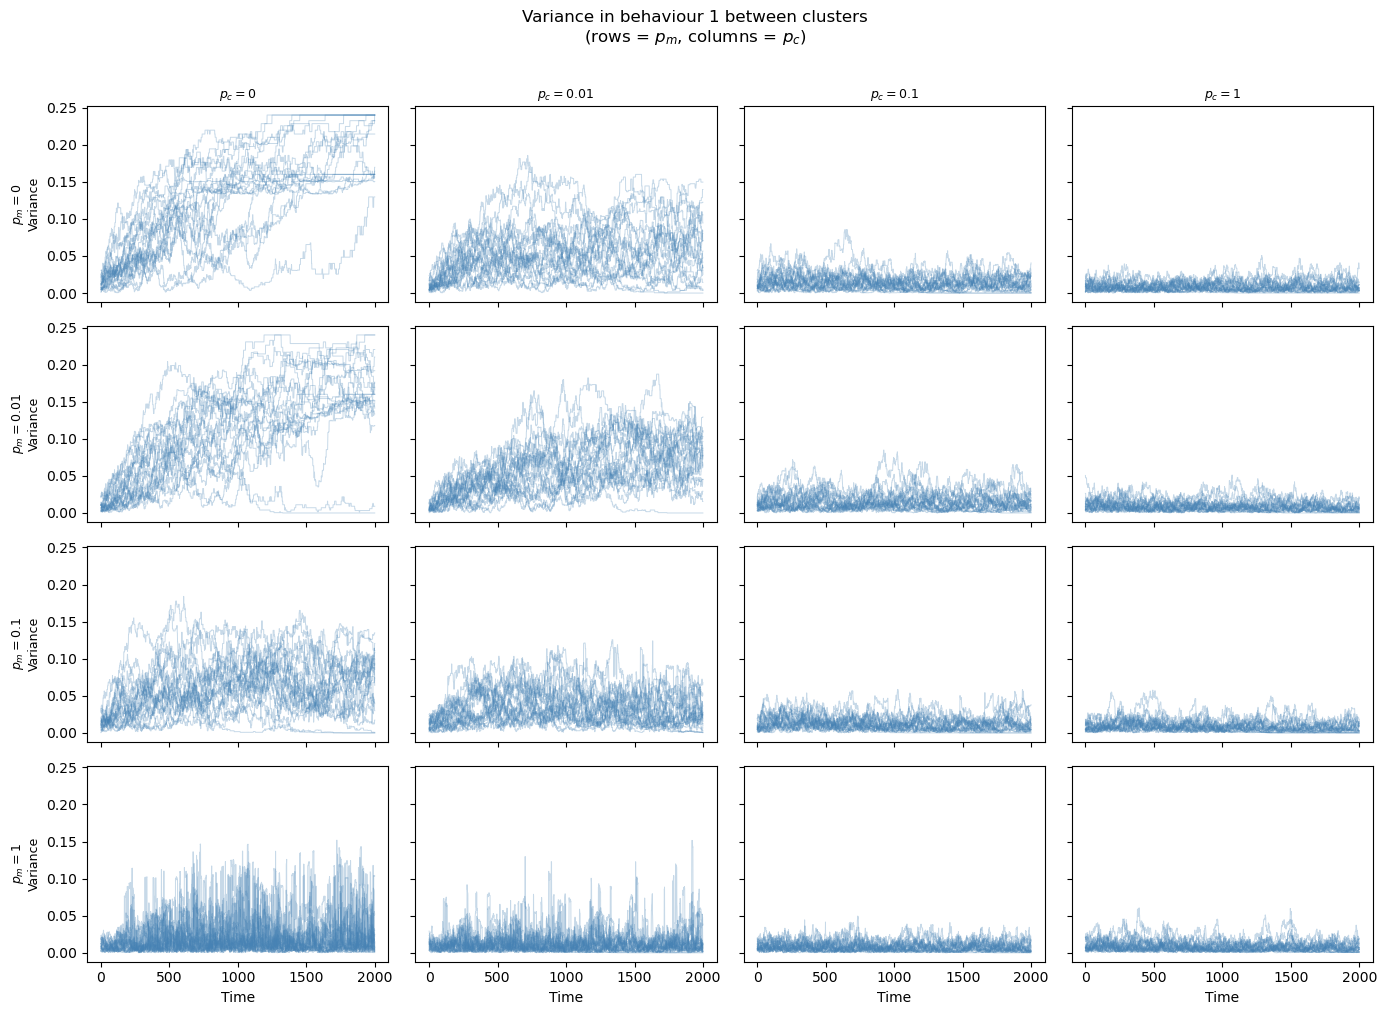

In [26]:
fig, axes = plt.subplots(len(pm_values), len(pc_values),
                         figsize=(14, 10), sharey=True, sharex=True)

for ri, pm in enumerate(pm_values):
    for ci, pc in enumerate(pc_values):
        ax = axes[ri, ci]
        sub = res[(res["p_m"] == pm) & (res["p_c"] == pc)]
        for sim_id, grp in sub.groupby("sim"):
            ax.plot(grp["time"], grp["var"], alpha=0.3, linewidth=0.7, color="steelblue")
        if ri == len(pm_values) - 1:
            ax.set_xlabel("Time")
        if ci == 0:
            ax.set_ylabel(f"$p_m={pm}$\nVariance", fontsize=9)
        if ri == 0:
            ax.set_title(f"$p_c={pc}$", fontsize=9)

plt.suptitle("Variance in behaviour 1 between clusters\n(rows = $p_m$, columns = $p_c$)", y=1.01)
plt.tight_layout()
plt.show()

In the absence of both contact and migration ($p_m = p_c = 0$) variance is highest (clusters diverge). Variance decreases as either parameter increases — but the rate differs: increasing $p_c$ reduces variance more quickly than the same increase in $p_m$.


### D4. Heatmap

To summarise more compactly, we average the variance over the **last 20 %** of time steps for each parameter pair:

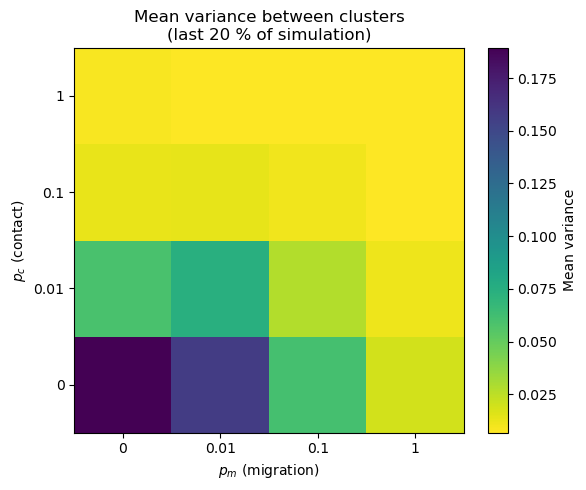

In [27]:
t_cutoff = res["time"].max() * 0.8
res_summ = (res[res["time"] >= t_cutoff]
            .groupby(["p_m", "p_c"], as_index=False)
            .agg(mean_var=("var", "mean")))

# Pivot for heatmap
heatmap_data = res_summ.pivot(index="p_c", columns="p_m", values="mean_var")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(heatmap_data.values, aspect="auto", origin="lower",
               cmap="viridis_r")
ax.set_xticks(range(len(pm_values)))
ax.set_xticklabels(pm_values)
ax.set_yticks(range(len(pc_values)))
ax.set_yticklabels(pc_values)
ax.set_xlabel("$p_m$ (migration)")
ax.set_ylabel("$p_c$ (contact)")
ax.set_title("Mean variance between clusters\n(last 20 % of simulation)")
plt.colorbar(im, ax=ax, label="Mean variance")
plt.tight_layout()
plt.show()

The heatmap confirms that contact and migration are **not interchangeable**: contact ($p_c$) homogenises clusters faster than the same level of migration ($p_m$).